In [1]:
import QUANTAXIS as QA
import pandas as pd
import tushare as ts
import numpy as np
# import TA-Lib as ta
import scipy.signal as signal
import matplotlib.pyplot as plt


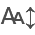

In [12]:
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

import tushare as ts
token = "488917d460bca13177c0b510492fc5fc04d0629bc76cc32a4f73fcf0"
ts.set_token(token)
pro = ts.pro_api()

# Prepare Data

In [149]:
df_qa_blk_list = QA.QA_fetch_index_list()

In [150]:
df_qa_blk_list=df_qa_blk_list[['name']].rename(columns={"name":"blk_name"})

In [155]:
df_qa_blk_list = df_qa_blk_list.loc['880302':'880497']
df_qa_blk_list = df_qa_blk_list.reset_index()

In [157]:
# len(df_qa_blk_list.loc['880302':'880497'])
# len(df_qa_blk_list)
df_qa_blk_list

code blk_name
0    880302     煤炭开采
1    880303     焦炭加工
2    880305       电力
3    880306     水力发电
4    880307     火力发电
..      ...      ...
126  880491      半导体
127  880492      元器件
128  880493     软件服务
129  880494      互联网
130  880497      综合类

[131 rows x 2 columns]

## stock basic

In [4]:
#查询当前所有正常上市交易的股票列表
df_stock_basic = pro.query('stock_basic', exchange='', list_status='L', fields='ts_code,symbol,market,name,area,industry,list_date')

In [5]:
df_stock_basic['city'] = df_stock_basic['ts_code'].map(lambda x: x.split('.')[1])
# need 5ms

In [111]:
# df_stock_basic.head(4)
# df_stock_basic[df_stock_basic[['industry']].isna()]
df_stock_basic= df_stock_basic.dropna(how='any')

In [133]:
# df_stock_basic[~df_stock_basic[['ts_code']].isna()]
# df_stock_basic[df_stock_basic[['ts_code']]=='000001.SZ']
df_stock_basic.query("ts_code == '000001.SZ'")

ts_code  symbol  name area industry market list_date city
0  000001.SZ  000001  平安银行   深圳       银行     主板  19910403   SZ

In [120]:
df_stock_basic

ts_code  symbol     name area industry market list_date city
0     000001.SZ  000001     平安银行   深圳       银行     主板  19910403   SZ
1     000002.SZ  000002      万科A   深圳     全国地产     主板  19910129   SZ
2     000004.SZ  000004     国华网安   深圳     软件服务     主板  19910114   SZ
3     000006.SZ  000006     深振业A   深圳     区域地产     主板  19920427   SZ
4     000007.SZ  000007    *ST全新   深圳     其他商业     主板  19920413   SZ
...         ...     ...      ...  ...      ...    ...       ...  ...
5357  873706.BJ  873706     铁拓机械   福建     工程机械    北交所  20240308   BJ
5358  873726.BJ  873726     卓兆点胶   江苏     机械基件    北交所  20231019   BJ
5359  873806.BJ  873806      云星宇   北京     软件服务    北交所  20240111   BJ
5360  873833.BJ  873833     美心翼申   重庆     汽车配件    北交所  20231108   BJ
5362  689009.SH  689009  九号公司-WD   北京      摩托车    科创板  20201029   SH

[5358 rows x 8 columns]

In [7]:
# %time df_stock_basic['city'] = df_stock_basic[['ts_code']].applymap(lambda x: x.split('.')[1])
# Wall time: 64.5 ms
# second time Wall time: 4 ms

In [8]:
# 筛选上证的股票
# df_stock_basic.query("symbol.str.startswith('6')", engine='python')

In [9]:
# df_stock_basic.market.unique()
# array(['主板', '创业板', '北交所', '科创板'], dtype=object)

## 获取所有股票市值

In [33]:
# 获取总市值，流通市值
df_total_mv = pro.query('daily_basic', ts_code='', trade_date='20240524',fields='ts_code,total_mv,circ_mv')
df_total_mv['total_mv'] = round(df_total_mv['total_mv'] / 10000,3)
df_total_mv['circ_mv'] = round(df_total_mv['circ_mv'] / 10000,3)
# ,dv_ratio,pe,pb

In [34]:
df_total_mv

ts_code  total_mv  circ_mv
0     600230.SH    49.604   49.094
1     688528.SH    14.549   14.549
2     605028.SH    25.808    6.452
3     600237.SH    35.063   33.609
4     002465.SZ   260.344  255.089
...         ...       ...      ...
5337  002880.SZ    67.314   67.314
5338  603031.SH    59.367   45.667
5339  002792.SZ    58.218   34.744
5340  603040.SH    27.994   27.867
5341  300617.SZ    45.823   25.665

[5342 rows x 3 columns]

In [158]:
# 将stock basic 和市值数据合并
df_stock = df_stock_basic.merge(df_total_mv, on='ts_code',how='left')\
.merge(df_qa_blk_list,left_on='industry',right_on='blk_name',how='left')

In [159]:
# len(df_stock['industry'].unique())
# 111
# df_stock['industry'].unique()
df_stock.dropna(inplace=True)

## 计算板块总市值, 总流通市值

In [161]:
# 计算板块 总市值 和 总流通市值
df_blk = df_stock.groupby('industry')[['total_mv','circ_mv']].sum().sort_values(by='circ_mv',ascending=False)\
    .rename(columns = {"total_mv":"blk_total_mv","circ_mv":"blk_circ_mv"})

In [162]:
# 合并 个股信息 和 板块信息
df_stock_blk = df_stock.merge(df_blk,on='industry',how='left')

In [163]:
df_stock_blk.head(5)

ts_code  symbol   name area industry market list_date city  total_mv  \
0  000001.SZ  000001   平安银行   深圳       银行     主板  19910403   SZ  2194.809   
1  000002.SZ  000002    万科A   深圳     全国地产     主板  19910129   SZ  1072.571   
2  000004.SZ  000004   国华网安   深圳     软件服务     主板  19910114   SZ    14.575   
3  000006.SZ  000006   深振业A   深圳     区域地产     主板  19920427   SZ    54.405   
4  000007.SZ  000007  *ST全新   深圳     其他商业     主板  19920413   SZ    16.283   

    circ_mv    code blk_name  blk_total_mv  blk_circ_mv  
0  2194.767  880471       银行    114991.986    78973.673  
1   873.553  880483     全国地产      5378.500     5008.947  
2    13.904  880493     软件服务     20112.966    16679.892  
3    54.404  880484     区域地产      3329.999     3132.154  
4    14.521  880411     其他商业       703.577      565.884

## 计算累计市值占比

In [164]:
# 计算市值占比 tot_mv_shr
df_stock_blk['tot_mv_shr'] = df_stock_blk['total_mv'] / df_stock_blk['blk_total_mv']

In [165]:
# 计算累计市值占比
df_cumsum = df_stock_blk.sort_values(by=['blk_total_mv','total_mv'],ascending=[False,False])\
.groupby('industry')[['tot_mv_shr']].cumsum().rename(columns={"tot_mv_shr":"tot_mv_shr_cumsum"})

In [166]:
df_cumsum1 = df_stock_blk.sort_values(by=['blk_total_mv','total_mv'],ascending=[False,False])\
.groupby('industry')[['tot_mv_shr']].cumsum().rename(columns={"tot_mv_shr":"tot_mv_shr_cumsum"})

In [167]:
df_cumsum

tot_mv_shr_cumsum
3725           0.168607
3822           0.322321
3706           0.455932
3834           0.570623
2875           0.646814
...                 ...
4316           1.000000
157            0.388264
3052           0.619224
1163           0.816893
201            1.000000

[5341 rows x 1 columns]

In [168]:
df_rank = df_stock_blk.groupby('industry')[['tot_mv_shr']].rank(ascending=False,method='dense').rename(columns={"tot_mv_shr":"rank_mv"})

In [169]:
df_rank

rank_mv
0        11.0
1         2.0
2       251.0
3        20.0
4        13.0
...       ...
5336     36.0
5337    112.0
5338    203.0
5339    233.0
5340      2.0

[5341 rows x 1 columns]

In [170]:
df_stock_cumsum_n_rank = df_cumsum.join(df_rank)

In [171]:
df_stock_cumsum_n_rank = df_stock_blk.join(df_cumsum).join(df_rank)

In [172]:
# df_stock_cumsum_n_rank.query("industry == '石油贸易'")

In [57]:
# df_stock.query("industry == '石油贸易'")

## 找出单寡头

In [173]:
df_single_monopoly = df_stock_cumsum_n_rank.query("rank_mv == 1 and tot_mv_shr_cumsum > 0.4")\
.filter(['symbol','name','industry','code','blk_total_mv','total_mv','tot_mv_shr_cumsum'])
df_single_monopoly

symbol  name industry    code  blk_total_mv   total_mv  \
537   002024  ST易购     电器连锁  880409       261.247    132.486   
941   002444  巨星科技     轻工机械  880442       487.617    312.771   
1761  300285  国瓷材料       陶瓷  880345       382.747    193.029   
2852  600009  上海机场       机场  880467      1726.634    889.134   
2868  600028  中国石化     石油加工  880312      9660.166   7815.688   
3166  600415  小商品城      商品城  880412       613.162    438.747   
3238  600519  贵州茅台       白酒  880381     38357.708  21067.442   
3307  600600  青岛啤酒       啤酒  880382      2042.982   1134.057   
3436  600754  锦江酒店     酒店餐饮  880423       733.031    298.649   
3550  600887  伊利股份      乳制品  880373      2653.568   1838.529   
3559  600900  长江电力     水力发电  880306     12480.510   6435.141   
3580  600941  中国移动     电信运营  880452     28572.527  20998.840   
3651  601088  中国神华     煤炭开采  880302     19296.582   8207.686   
3788  601816  京沪高铁       铁路  880460      4355.064   2519.163   
3794  601857  中国石油     石油开采  880311     34954.557  18247.191   
3808  601888  中国中免     旅游服务  880425      1906.138   1523.922   
3811  601899  紫金矿业        铜  880325      8208.026   4691.291   
3817  601919  中远海控       水运  880461      5566.699   2256.403   
4525  605499  东鹏饮料      软饮料  880374      1696.876    888.022   

      tot_mv_shr_cumsum  
537            0.507129  
941            0.641428  
1761           0.504325  
2852           0.514952  
2868           0.809064  
3166           0.715548  
3238           0.549236  
3307           0.555099  
3436           0.407417  
3550           0.692852  
3559           0.515615  
3580           0.734931  
3651           0.425344  
3788           0.578445  
3794           0.522026  
3808           0.799481  
3811           0.571549  
3817           0.405340  
4525           0.523328

In [174]:
df_single_monopoly['code'].values

array(['880409', '880442', '880345', '880467', '880312', '880412',
       '880381', '880382', '880423', '880373', '880306', '880452',
       '880302', '880460', '880311', '880425', '880325', '880461',
       '880374'], dtype=object)

## 找出双寡头

In [175]:
df_one_n_two_monopoly = df_stock_cumsum_n_rank.query("rank_mv == 2 and tot_mv_shr_cumsum > 0.4")\
.filter(['symbol','name','industry','blk_total_mv','total_mv','tot_mv_shr_cumsum','rank_mv'])
# df_one_n_two_monopoly

In [176]:
df_one_n_two_monopoly_temp =df_one_n_two_monopoly[['industry','name','rank_mv']].rename(columns={"rank_mv":"top2"})
# df_one_n_two_monopoly_temp

In [177]:
df_stock_cumsum_n_rank_temp =df_stock_cumsum_n_rank.merge(df_one_n_two_monopoly_temp, on='industry', how='left')

In [178]:
df_stock_cumsum_n_rank_temp1 = df_stock_cumsum_n_rank_temp.dropna()\
.query("rank_mv<=top2").filter(['symbol','name','industry','code','blk_total_mv','total_mv','tot_mv_shr','tot_mv_shr_cumsum','rank_mv'])

In [179]:
df_one_n_two_monopoly_temp

industry  name  top2
1        全国地产   万科A   2.0
37        商品城   深赛格   2.0
61       石油贸易  国际实业   2.0
195       批发业  泰达股份   2.0
324        白酒   五粮液   2.0
331       红黄酒   张裕A   2.0
333        饲料   新希望   2.0
334        水泥  天山股份   2.0
600      商贸代理  江苏国泰   2.0
773      其他建材  东方雨虹   2.0
915      电器连锁   爱施德   2.0
928      化工机械  杭氧股份   2.0
1097     轻工机械  东方精工   2.0
1249     农用机械  中坚科技   2.0
1463       陶瓷  东鹏控股   2.0
1960     农业综合  温氏股份   2.0
2853       普钢  包钢股份   2.0
2865     水力发电  华能水电   2.0
2866       水运  中远海能   2.0
2869       空运  南方航空   2.0
2948       啤酒  重庆啤酒   2.0
2953     旅游服务   中青旅   2.0
2980       玻璃  中国巨石   2.0
3048     酒店餐饮  首旅酒店   2.0
3052       林业  景谷林业   2.0
3075      特种钢  鄂尔多斯   2.0
3076     汽车服务  广汇汽车   2.0
3114     石油加工  恒力石化   2.0
3127        铜  江西铜业   2.0
3196       渔业   好当家   2.0
3212       黄金  中金黄金   2.0
3234       机场  海南机场   2.0
3304      乳制品  光明乳业   2.0
3379     家用电器  海尔智家   2.0
3498     超市连锁  百联股份   2.0
3578     石油开采  中国海油   2.0
3616     焦炭加工  开滦股份   2.0
3624       铁路  大秦铁路   2.0
3633       港口   宁波港   2.0
3697     煤炭开采  陕西煤业   2.0
3709       保险  中国平安   2.0
3756     汽车整车  长城汽车   2.0
3776     电信运营  中国电信   2.0
3833     新型电力  中国核电   2.0
3835       船舶  中国重工   2.0
3875       橡胶  三维股份   2.0
3904     公共交通  海汽集团   2.0
3967      软饮料  养元饮品   2.0
4101     纺织机械  杰克股份   2.0
4185       公路  长久物流   2.0
4700     运输设备  时代电气   2.0

In [180]:
# 排除df_single_monopoly
df_top2_raw = df_stock_cumsum_n_rank_temp1.merge(df_single_monopoly[['industry','name']],on='industry',how='left')
# df_top2_raw.head(4)
df_two_monopoly = df_top2_raw[df_top2_raw['name'].isnull()].sort_values(by=['blk_total_mv','rank_mv'],ascending=[False,True])
df_two_monopoly

symbol industry    code  blk_total_mv  total_mv  tot_mv_shr  \
78  601628       保险  880473     23367.452  9027.747    0.386339   
77  601318       保险  880473     23367.452  7992.472    0.342034   
4   000333     家用电器  880387     18555.829  4646.957    0.250431   
61  600690     家用电器  880387     18555.829  2837.097    0.152895   
23  002594     汽车整车  880391     16421.532  6089.093    0.370799   
..     ...      ...     ...           ...       ...         ...   
52  600467       渔业  880362       161.275    28.928    0.179371   
97  603223       公路  880463       138.364    54.635    0.394864   
99  603569       公路  880463       138.364    49.665    0.358945   
5   000592       林业  880363       101.498    39.408    0.388264   
46  600265       林业  880363       101.498    23.442    0.230960   

    tot_mv_shr_cumsum  rank_mv name  
78           0.386339      1.0  NaN  
77           0.728373      2.0  NaN  
4            0.250431      1.0  NaN  
61           0.403326      2.0  NaN  
23           0.370799      1.0  NaN  
..                ...      ...  ...  
52           0.407416      2.0  NaN  
97           0.394864      1.0  NaN  
99           0.753809      2.0  NaN  
5            0.388264      1.0  NaN  
46           0.619224      2.0  NaN  

[64 rows x 9 columns]

In [181]:
df_two_monopoly['code'].unique()

array(['880473', '880387', '880391', '880308', '880366', '880432',
       '880319', '880483', '880462', '880468', '880431', '880328',
       '880346', '880364', '880347', '880348', '880320', '880414',
       '880441', '880339', '880383', '880303', '880408', '880393',
       '880443', '880444', '880453', '880413', '880313', '880362',
       '880463', '880363'], dtype=object)

## 找出3寡头 占比超过50%

In [182]:
df_one_two_three_monopoly = df_stock_cumsum_n_rank.query("rank_mv == 3 and tot_mv_shr_cumsum > 0.5")\
.filter(['symbol','name','industry','code','blk_total_mv','total_mv','tot_mv_shr_cumsum','rank_mv'])
df_one_two_three_monopoly

symbol  name industry    code  blk_total_mv  total_mv  \
132   000554  泰山石油     石油贸易  880313       165.728    27.069   
184   000630  铜陵有色        铜  880325      8208.026   500.347   
194   000651  格力电器     家用电器  880387     18555.829  2318.450   
249   000729  燕京啤酒       啤酒  880382      2042.982   271.989   
406   000975  银泰黄金       黄金  880328      3466.089   521.746   
469   001289  龙源电力     新型电力  880308      8984.885  1534.026   
491   001331  胜通能源       公路  880463       138.364    22.344   
516   001979  招商蛇口     全国地产  880483      5378.500   910.614   
591   002080  中材科技       玻璃  880347      2603.194   263.298   
662   002157  正邦科技     农业综合  880366      7079.821   298.468   
819   002318  久立特材      特种钢  880320      2032.728   235.889   
872   002372  伟星新材     其他建材  880348      2254.910   273.353   
1163  002679  福建金森       林业  880363       101.498    20.063   
1179  002697  红旗连锁     超市连锁  880408       662.705    68.544   
1180  002698  博实股份     化工机械  880441      1044.227   142.545   
1187  002707  众信旅游     旅游服务  880425      1906.138    62.599   
1231  002758  浙农股份      批发业  880413       236.215    48.295   
1376  002918  蒙娜丽莎       陶瓷  880345       382.747    49.448   
1401  002946   新乳业      乳制品  880373      2653.568    90.900   
1641  300159  新研股份     农用机械  880444       513.740    43.320   
1655  300173  福能东方     轻工机械  880442       487.617    30.418   
2360  300917  特发服务     房产服务  880486       558.940    76.658   
2848  600004  白云机场       机场  880467      1726.634   240.932   
2851  600008  首创环保       水务  880454      1363.333   216.547   
2880  600050  中国联通     电信运营  880452     28572.527  1466.007   
2889  600059  古越龙山      红黄酒  880383       720.672    79.395   
2922  600104  上汽集团     汽车整车  880391     16421.532  1642.535   
2933  600115  中国东航       空运  880462      4895.059   880.506   
2991  600188  兖矿能源     煤炭开采  880302     19296.582  1850.567   
3047  600257  大湖股份       渔业  880362       161.275    26.131   
3078  600299   安迪苏       饲料  880364      2876.281   266.045   
3106  600335  国机汽车     汽车服务  880393       658.866   101.115   
3116  600350  山东高速       路桥  880466      3480.981   422.567   
3207  600482  中国动力       船舶  880431      4185.344   429.770   
3348  600650  锦江在线     公共交通  880453       251.844    44.349   
3377  600688  上海石化     石油加工  880312      9660.166   299.140   
3395  600710   苏美达     商贸代理  880414      1190.949   108.722   
3424  600740  山西焦化     焦炭加工  880303       710.101   115.808   
3465  600790   轻纺城      商品城  880412       613.162    52.768   
3475  600801  华新水泥       水泥  880346      3262.911   319.334   
3482  600809  山西汾酒       白酒  880381     38357.708  3076.018   
3511  600843  上工申贝     纺织机械  880443       567.849    63.472   
3549  600886  国投电力     水力发电  880306     12480.510  1252.302   
3556  600895  张江高科     园区开发  880485      2051.025   266.220   
3707  601298   青岛港       港口  880468      4881.998   543.305   
3714  601333  广深铁路       铁路  880460      4355.064   235.882   
3745  601601  中国太保       保险  880473     23367.452  2781.241   
3786  601808  中海油服     石油开采  880311     34954.557   850.775   
3801  601872  招商轮船       水运  880461      5566.699   742.715   
3954  603129  春风动力      摩托车  880394      1501.128   235.855   
4429  605008  长鸿高科       橡胶  880339       761.323    98.186   
4455  605108   同庆楼     酒店餐饮  880423       733.031    66.768   
4483  605198   安德利      软饮料  880374      1696.876   128.188   
4545  688009  中国通号     运输设备  880432      5492.711   595.148   

      tot_mv_shr_cumsum  rank_mv  
132            0.656986      3.0  
184            0.740802      3.0  
194            0.528271      3.0  
249            0.854177      3.0  
406            0.727442      3.0  
469            0.597955      3.0  
491            0.915296      3.0  
516            0.605084      3.0  
591            0.516161      3.0  
662            0.619416      3.0  
819            0.650686      3.0  
872            0.552685      3.0  
1163           0.816893      3.0  
1179           0.665702      3.0  
1180           

In [183]:
df_one_two_three_monopoly_temp = df_one_two_three_monopoly[['industry','name','rank_mv']].rename(columns={"rank_mv":"top3"})

In [184]:
df_stock_cumsum_n_rank_temp3 =df_stock_cumsum_n_rank.merge(df_one_two_three_monopoly_temp, on='industry', how='left')

In [185]:
df_stock_cumsum_n_rank_temp1 = df_stock_cumsum_n_rank_temp3.dropna()\
.query("rank_mv<=top3").filter(['symbol','name','industry','code','blk_total_mv','total_mv','tot_mv_shr','tot_mv_shr_cumsum','rank_mv'])

In [186]:
# 排除df_single_monopoly
df_top3_raw = df_stock_cumsum_n_rank_temp1.merge(df_one_n_two_monopoly_temp[['industry','name']],on='industry',how='left')
# df_top2_raw.head(4)
df_three_monopoly = df_top3_raw[df_top3_raw['name'].isnull()].sort_values(by=['blk_total_mv','rank_mv'],ascending=[False,True])
df_three_monopoly

symbol industry    code  blk_total_mv  total_mv  tot_mv_shr  \
24   001965       路桥  880466      3480.981   774.790    0.222578   
84   600377       路桥  880466      3480.981   580.852    0.166864   
82   600350       路桥  880466      3480.981   422.567    0.121393   
97   600663     园区开发  880485      2051.025   491.882    0.239823   
108  600848     园区开发  880485      2051.025   274.951    0.134055   
111  600895     园区开发  880485      2051.025   266.220    0.129799   
153  603529      摩托车  880394      1501.128   298.230    0.198671   
161  689009      摩托车  880394      1501.128   282.374    0.188108   
149  603129      摩托车  880394      1501.128   235.855    0.157119   
123  601158       水务  880454      1363.333   247.200    0.181320   
8    000598       水务  880454      1363.333   220.293    0.161584   
57   600008       水务  880454      1363.333   216.547    0.158836   
23   001914     房产服务  880486       558.940   125.015    0.223664   
6    000560     房产服务  880486       558.940    78.203    0.139913   
55   300917     房产服务  880486       558.940    76.658    0.137149   

     tot_mv_shr_cumsum  rank_mv name  
24            0.222578      1.0  NaN  
84            0.389443      2.0  NaN  
82            0.510836      3.0  NaN  
97            0.239823      1.0  NaN  
108           0.373878      2.0  NaN  
111           0.503676      3.0  NaN  
153           0.198671      1.0  NaN  
161           0.386778      2.0  NaN  
149           0.543897      3.0  NaN  
123           0.181320      1.0  NaN  
8             0.342904      2.0  NaN  
57            0.501741      3.0  NaN  
23            0.223664      1.0  NaN  
6             0.363577      2.0  NaN  
55            0.500726      3.0  NaN

In [187]:
df_three_monopoly['code'].unique()

array(['880466', '880485', '880394', '880454', '880486'], dtype=object)

## 找出剩余板块

In [206]:
df_temp = df_stock_cumsum_n_rank.merge(df_one_two_three_monopoly_temp,on='industry', how='left')

In [216]:
# 修改打印选项以显示完整的数组
np.set_printoptions(threshold=np.inf)  # np.inf 表示无限制

In [222]:
df_temp1 = df_temp[df_temp['top3'].isnull()]['code'].unique()
df_temp1

array(['880471', '880493', '880484', '880411', '880446', '880477',
       '880369', '880492', '880497', '880307', '880410', '880392',
       '880456', '880327', '880490', '880489', '880401', '880420',
       '880447', '880472', '880330', '880402', '880455', '880337',
       '880438', '880474', '880407', '880403', '880426', '880350',
       '880398', '880375', '880336', '880445', '880422', '880439',
       '880340', '880421', '880326', '880329', '880319', '880494',
       '880430', '880361', '880419', '880368', '880321', '880351',
       '880338', '880464', '880399', '880448', '880491', '880355',
       '880409', '880478'], dtype=object)

In [224]:
df_temp[df_temp['top3'].isnull()].query('rank_mv <=3')

ts_code  symbol  name_x area industry market list_date city  total_mv  \
39    000060.SZ  000060    中金岭南   深圳       铅锌     主板  19970123   SZ   172.677   
42    000063.SZ  000063    中兴通讯   深圳     通信设备     主板  19971118   SZ  1281.911   
54    000100.SZ  000100   TCL科技   广东      元器件     主板  20040130   SZ   831.913   
59    000157.SZ  000157    中联重科   湖南     工程机械     主板  20001012   SZ   715.934   
63    000301.SZ  000301    东方盛虹   江苏       化纤     主板  20000529   SZ   611.537   
...         ...     ...     ...  ...      ...    ...       ...  ...       ...   
4744  688235.SH  688235  百济神州-U   北京     生物制药    科创板  20211215   SH  1650.772   
4771  688271.SH  688271    联影医疗   上海     医疗保健    科创板  20220822   SH  1050.389   
4828  688333.SH  688333     铂力特   陕西     机械基件    科创板  20190722   SH   168.496   
4930  688506.SH  688506  百利天恒-U   四川     化学制药    科创板  20230106   SH   720.276   
5107  688981.SH  688981    中芯国际   上海      半导体    科创板  20200716   SH  3263.762   

       circ_mv    code blk_name  blk_total_mv  blk_circ_mv  tot_mv_shr  \
39     172.664  880327       铅锌      1640.837     1426.222    0.105237   
42    1079.242  880490     通信设备     18955.413    16823.739    0.067628   
54     801.765  880492      元器件     27939.730    23111.100    0.029775   
59     583.317  880447     工程机械      6524.220     5690.452    0.109735   
63     508.474  880330       化纤      4544.209     4042.443    0.134575   
...        ...     ...      ...           ...          ...         ...   
4744   139.758  880402     生物制药     11665.606     8065.324    0.141508   
4771   751.062  880398     医疗保健     19260.686    16054.658    0.054535   
4828   140.679  880439     机械基件      4846.846     3622.918    0.034764   
4930   162.468  880401     化学制药     17737.213    14777.698    0.040608   
5107   809.772  880491      半导体     30290.821    20937.535    0.107748   

      tot_mv_shr_cumsum  rank_mv name_y  top3  
39             0.438921      3.0    NaN   NaN  
42             0.390989      3.0    NaN   NaN  
54             0.167733      3.0    NaN   NaN  
59             0.470808      3.0    NaN   NaN  
63             0.366088      2.0    NaN   NaN  
...                 ...      ...    ...   ...  
4744           0.141508      1.0    NaN   NaN  
4771           0.304131      3.0    NaN   NaN  
4828           0.072627      2.0    NaN   NaN  
4930           0.263421      3.0    NaN   NaN  
5107           0.107748      1.0    NaN   NaN  

[167 rows x 19 columns]

In [71]:
df_no_monopoly.industry.unique()

array(['银行', '电气设备', '半导体', '证券', '元器件', '化工原料', '软件服务', '医疗保健', '通信设备',
       '化学制药', '汽车配件', '建筑工程', '专用机械', '生物制药', '食品', '小金属', 'IT设备', '中成药',
       '火力发电', '航空', '互联网', '工程机械', '仓储物流', '电器仪表', '农药化肥', '环境保护', '普钢',
       '铝', '服饰', '机械基件', '化纤', '多元金融', '医药商业', '影视音像', '供气供热', '区域地产',
       '广告包装', '家居用品', '塑料', '出版业', '文教休闲', '矿物制品', '造纸', '百货', '染料涂料',
       '日用化工', '铅锌', '纺织', '钢加工', '机床制造', '种植业', '综合类', '旅游景点', '装修装饰',
       '其他商业', '电器连锁', None], dtype=object)

In [ ]:
df_stock_cumsum_n_rank

In [191]:
# 计算多少个股 才能到50%的行业占比 
df_blk_50_pct_count1 = df_blk_50_pct1.groupby('industry')[['ts_code']].count().rename(columns={"ts_code":"stock_count"})
# .sort_values(by='blk_total_mv',ascending=False)

In [192]:
df_stock_50_pct_count1 = df_blk_50_pct1.merge(df_blk_50_pct_count1,on='industry')

In [194]:
df_stock_50_pct_count1.query("stock_count <2").sort_values(by=['blk_total_mv','tot_mv_shr'],ascending=[False,False])

ts_code  symbol  name area industry market list_date city  total_mv  \
573  601628.SH  601628  中国人寿   北京       保险     主板  20070109   SH    9027.7   
562  601088.SH  601088  中国神华   北京     煤炭开采     主板  20071009   SH    8207.7   
493  002594.SZ  002594   比亚迪   深圳     汽车整车     主板  20110630   SZ    6089.1   
494  002714.SZ  002714  牧原股份   河南     农业综合     主板  20140128   SZ    2626.1   
576  601919.SH  601919  中远海控   天津       水运     主板  20070626   SH    2256.4   
533  600150.SH  600150  中国船舶   上海       船舶     主板  19980520   SH    1585.9   
555  600547.SH  600547  山东黄金   山东       黄金     主板  20030828   SH    1291.9   
556  600585.SH  600585  海螺水泥   安徽       水泥     主板  20020207   SH    1294.6   
289  000708.SZ  000708  中信特钢   湖北      特种钢     主板  19970326   SZ     762.1   
469  002353.SZ  002353  杰瑞股份   山东     化工机械     主板  20100205   SZ     344.1   
561  600754.SH  600754  锦江酒店   上海     酒店餐饮     主板  19961011   SH     298.6   
492  002568.SZ  002568  百润股份   上海      红黄酒     主板  20110325   SZ     232.0   
290  000723.SZ  000723  美锦能源   山西     焦炭加工     主板  19970515   SZ     236.2   
577  601933.SH  601933  永辉超市   福建     超市连锁     主板  20101215   SH     215.1   
578  603025.SH  603025  大豪科技   北京     纺织机械     主板  20150422   SH     152.1   
579  603071.SH  603071  物产环能   浙江      批发业     主板  20211216   SH      82.5   
580  603223.SH  603223  恒通股份   山东       公路     主板  20150630   SH      54.6   
246  000592.SZ  000592  平潭发展   福建       林业     主板  19960327   SZ      39.4   

     circ_mv  blk_total_mv  blk_circ_mv  tot_mv_shr  tot_mv_shr_cumsum  \
573   6651.0       23367.3      16087.1    0.386339           0.386339   
562   6812.4       19296.8      16124.5    0.425340           0.425340   
493   2433.1       16421.6      11341.6    0.370798           0.370798   
494   1758.9        7080.3       5318.6    0.370902           0.370902   
576   1804.0        5566.7       4407.1    0.405339           0.405339   
533   1585.9        4185.6       3841.1    0.378894           0.378894   
555   1043.9        3466.0       3061.8    0.372735           0.372735   
556    977.1        3262.8       2255.4    0.396776           0.396776   
289    762.1        2032.7       1927.0    0.374920           0.374920   
469    233.1        1044.2        847.8    0.329535           0.329535   
561    255.1         733.0        652.0    0.407367           0.407367   
492    158.5         720.7        588.3    0.321909           0.321909   
290    234.6         710.0        703.9    0.332676           0.332676   
577    215.1         662.6        625.1    0.324630           0.324630   
578    152.1         567.9        541.4    0.267829           0.267829   
579     35.2         236.2        170.5    0.349280           0.349280   
580     42.3         138.3        107.6    0.394794           0.394794   
246     39.0         101.5         99.4    0.388177           0.388177   

     stock_count  
573            1  
562            1  
493            1  
494            1  
576            1  
533            1  
555            1  
556            1  
289            1  
469            1  
561            1  
492            1  
290            1  
577            1  
578            1  
579            1  
580            1  
246            1

In [ ]:
df_blk_50_pct.query("")

In [187]:
df_blk_40_pct = df_stock_cumsum.query("tot_mv_shr_cumsum < 0.4")

In [188]:
df_blk_40_pct.sort_values(by=['blk_total_mv','total_mv'],ascending=[False,False])

ts_code  symbol  name area industry market list_date city  total_mv  \
3746  601398.SH  601398  工商银行   北京       银行     主板  20061027   SH   19388.5   
3843  601939.SH  601939  建设银行   北京       银行     主板  20070925   SH   17675.8   
2213  300750.SZ  300750  宁德时代   福建     电气设备    创业板  20180611   SZ    8841.2   
3180  600406.SH  600406  国电南瑞   江苏     电气设备     主板  20031016   SH    1786.5   
1760  300274.SZ  300274  阳光电源   安徽     电气设备    创业板  20111102   SZ    1502.2   
...         ...     ...   ...  ...      ...    ...       ...  ...       ...   
3927  603071.SH  603071  物产环能   浙江      批发业     主板  20211216   SH      82.5   
53    000096.SZ  000096  广聚能源   深圳     石油贸易     主板  20000724   SZ      54.7   
1587  300094.SZ  300094  国联水产   广东       渔业    创业板  20100708   SZ      36.8   
4045  603223.SH  603223  恒通股份   山东       公路     主板  20150630   SH      54.6   
159   000592.SZ  000592  平潭发展   福建       林业     主板  19960327   SZ      39.4   

      circ_mv  blk_total_mv  blk_circ_mv  tot_mv_shr  tot_mv_shr_cumsum  
3746  14666.9      114992.5      78973.7    0.168607           0.168607  
3843    678.3      114992.5      78973.7    0.153713           0.322319  
2213   7827.9       43969.9      36815.1    0.201074           0.201074  
3180   1775.7       43969.9      36815.1    0.040630           0.241704  
1760   1153.0       43969.9      36815.1    0.034164           0.275868  
...       ...           ...          ...         ...                ...  
3927     35.2         236.2        170.5    0.349280           0.349280  
53       52.9         165.7        155.3    0.330115           0.330115  
1587     36.0         161.3        160.5    0.228146           0.228146  
4045     42.3         138.3        107.6    0.394794           0.394794  
159      39.0         101.5         99.4    0.388177           0.388177  

[354 rows x 14 columns]

In [137]:
# 计算多少个股 才能到40%的行业占比 
df_blk_40_pct_count = df_blk_40_pct.groupby('industry')[['ts_code']].count().rename(columns={"ts_code":"stock_count"})
# .sort_values(by='blk_total_mv',ascending=False)

In [138]:
df_stock_40_pct_count = df_blk_40_pct.merge(df_blk_40_pct_count,on='industry')

In [139]:
df_stock_40_pct_count.query("stock_count<=3").sort_values(by=['blk_total_mv','tot_mv_shr_cumsum'],ascending = [False,True])

ts_code  symbol  name area industry market list_date city  \
342  601398.SH  601398  工商银行   北京       银行     主板  20061027   SH   
343  601939.SH  601939  建设银行   北京       银行     主板  20070925   SH   
344  601628.SH  601628  中国人寿   北京       保险     主板  20070109   SH   
44   601138.SH  601138  工业富联   深圳     通信设备     主板  20180608   SH   
43   300308.SZ  300308  中际旭创   山东     通信设备    创业板  20120410   SZ   
..         ...     ...   ...  ...      ...    ...       ...  ...   
350  603071.SH  603071  物产环能   浙江      批发业     主板  20211216   SH   
45   000096.SZ  000096  广聚能源   深圳     石油贸易     主板  20000724   SZ   
295  300094.SZ  300094  国联水产   广东       渔业    创业板  20100708   SZ   
351  603223.SH  603223  恒通股份   山东       公路     主板  20150630   SH   
135  000592.SZ  000592  平潭发展   福建       林业     主板  19960327   SZ   

         total_mv       circ_mv  blk_total_mv   blk_circ_mv  total_mv_share  \
342  1.938850e+08  1.466690e+08  1.149920e+09  7.897367e+08        0.168607   
343  1.767578e+08  6.782716e+06  1.149920e+09  7.897367e+08        0.153713   
344  9.027747e+07  6.651035e+07  2.336745e+08  1.608719e+08        0.386339   
44   4.797163e+07  4.790149e+07  1.895542e+08  1.682375e+08        0.253076   
43   1.332279e+07  1.325838e+07  1.895542e+08  1.682375e+08        0.070285   
..            ...           ...           ...           ...             ...   
350  8.252146e+05  3.515358e+05  2.362155e+06  1.704656e+06        0.349348   
45   5.470080e+05  5.292385e+05  1.657266e+06  1.553947e+06        0.330067   
295  3.677825e+05  3.602558e+05  1.612755e+06  1.604926e+06        0.228046   
351  5.463531e+05  4.231907e+05  1.383644e+06  1.076080e+06        0.394865   
135  3.940833e+05  3.904431e+05  1.014980e+06  9.945663e+05        0.388267   

     tot_mv_shr_cumsum  stock_count  
342           0.168607            2  
343           0.322321            2  
344           0.386339            1  
44            0.253076            3  
43            0.323361            3  
..                 ...          ...  
350           0.349348            1  
45            0.330067            1  
295           0.228046            1  
351           0.394865            1  
135           0.388267            1  

[99 rows x 15 columns]

In [140]:
df_stock_40_pct_count.query("stock_count > 3").sort_values(by=['blk_total_mv','tot_mv_shr_cumsum'],ascending = [False,True])

ts_code  symbol   name area industry market list_date city  \
276  300750.SZ  300750   宁德时代   福建     电气设备    创业板  20180611   SZ   
278  600406.SH  600406   国电南瑞   江苏     电气设备     主板  20031016   SH   
275  300274.SZ  300274   阳光电源   安徽     电气设备    创业板  20111102   SZ   
280  601012.SH  601012   隆基绿能   陕西     电气设备     主板  20120411   SH   
279  600438.SH  600438   通威股份   四川     电气设备     主板  20040302   SH   
..         ...     ...    ...  ...      ...    ...       ...  ...   
221  603889.SH  603889   新澳股份   浙江       纺织     主板  20141231   SH   
222  002081.SZ  002081    金螳螂   江苏     装修装饰     主板  20061120   SZ   
224  002482.SZ  002482  *ST广田   深圳     装修装饰     主板  20100929   SZ   
225  601886.SH  601886   江河集团   北京     装修装饰     主板  20110818   SH   
223  002163.SZ  002163   海南发展   深圳     装修装饰     主板  20070823   SZ   

         total_mv       circ_mv  blk_total_mv   blk_circ_mv  total_mv_share  \
276  8.841193e+07  7.827875e+07  4.397000e+08  3.681455e+08        0.201073   
278  1.786500e+07  1.775749e+07  4.397000e+08  3.681455e+08        0.040630   
275  1.502230e+07  1.153041e+07  4.397000e+08  3.681455e+08        0.034165   
280  1.421641e+07  1.421640e+07  4.397000e+08  3.681455e+08        0.032332   
279  1.024649e+07  1.024649e+07  4.397000e+08  3.681455e+08        0.023303   
..            ...           ...           ...           ...             ...   
221  5.552985e+05  5.444982e+05  1.429389e+07  1.226806e+07        0.038849   
222  9.426399e+05  9.382847e+05  8.038937e+06  7.406369e+06        0.117259   
224  7.651963e+05  7.635684e+05  8.038937e+06  7.406369e+06        0.095186   
225  6.764022e+05  6.764022e+05  8.038937e+06  7.406369e+06        0.084141   
223  5.872457e+05  5.584672e+05  8.038937e+06  7.406369e+06        0.073050   

     tot_mv_shr_cumsum  stock_count  
276           0.201073            9  
278           0.241703            9  
275           0.275868            9  
280           0.308200            9  
279           0.331504            9  
..                 ...          ...  
221           0.393518            7  
222           0.117259            4  
224           0.212446            4  
225           0.296586            4  
223           0.369636            4  

[255 rows x 15 columns]

In [57]:
 pro.query('daily_basic', ts_code='', trade_date='20240524',fields='ts_code,total_share,float_share, free_share')

,ts_code,total_share,float_share,free_share
0,600230.SH,41614.4936,41186.3502,22139.6078
1,688528.SH,16800.0000,16800.0000,5526.0960
2,605028.SH,16000.0000,4000.0000,4000.0000
3,600237.SH,63062.9155,60448.4178,49277.8199
4,002465.SZ,248183.3948,243173.1461,179512.4224
...,...,...,...,...
5337,002880.SZ,22680.0000,22680.0000,6237.0000
5338,603031.SH,21112.0000,16240.0000,8829.9867
5339,002792.SZ,40205.6966,23994.2292,18663.3116
5340,603040.SH,13510.7896,13449.1196,6064.0521
